# Deutsch-Jozsa: simulator-only version

This notebook is the clean simulator baseline for the course Deutsch-Jozsa notebook. It uses a deterministic balanced oracle so the simulator and IBM hardware results can be compared directly.

**Main comparison target:** `n = 4` input qubits, expected balanced output `1111`.

For Deutsch-Jozsa, the exact bitstring for a balanced oracle depends on oracle design. With this course-style oracle where every input qubit controls the output qubit, the ideal output is `1111`. For a constant oracle, the ideal output is `0000`.

In [ ]:
%pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b75e267458efcdc5462f5342a7c9ccd9293e047d04cab32eb8d08f46fc0d18d7
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

SHOTS = 4096


In [ ]:
def make_balanced_oracle(n: int) -> QuantumCircuit:
    """Balanced Deutsch-Jozsa oracle.

    Implements f(x) = x0 XOR x1 XOR ... XOR x(n-1) by applying a CNOT
    from every input qubit to the output/ancilla qubit.
    This is the same basic balanced-oracle form used in the course notebook.
    """
    oracle = QuantumCircuit(n + 1, name="Balanced Oracle")
    for qubit in range(n):
        oracle.cx(qubit, n)
    return oracle


def make_constant_oracle(n: int, output: int = 0) -> QuantumCircuit:
    """Constant Deutsch-Jozsa oracle.

    output=0: f(x)=0 for all x, so do nothing.
    output=1: f(x)=1 for all x, so flip the output/ancilla qubit.
    """
    oracle = QuantumCircuit(n + 1, name=f"Constant Oracle f={output}")
    if output == 1:
        oracle.x(n)
    return oracle


def deutsch_jozsa_circuit(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """Build the Deutsch-Jozsa circuit for an n-bit input register.

    Qubits 0..n-1 are the input register.
    Qubit n is the output/ancilla qubit.
    We measure only the input register.
    """
    qc = QuantumCircuit(n + 1, n)

    # Prepare input register in superposition.
    for qubit in range(n):
        qc.h(qubit)

    # Prepare output qubit in |->.
    qc.x(n)
    qc.h(n)
    qc.barrier(label="prep")

    # Apply oracle.
    qc.compose(oracle, qubits=range(n + 1), inplace=True)
    qc.barrier(label="oracle")

    # Interference step.
    for qubit in range(n):
        qc.h(qubit)

    qc.barrier(label="measure")

    # Measure q[i] into c[i].
    # Note: Qiskit displays bitstrings in classical-register order c[n-1]...c[0].
    for i in range(n):
        qc.measure(i, i)

    return qc


def classify_deutsch_jozsa_counts(counts: dict, n: int) -> str:
    """Classify DJ result from counts.

    For Deutsch-Jozsa:
    - all-zero measured input register means constant
    - any nonzero dominant bitstring means balanced
    """
    dominant = max(counts, key=counts.get)
    zero = "0" * n
    return "constant" if dominant == zero else "balanced"


## 1. Build the 4-input balanced Deutsch-Jozsa circuit

This matches the representative course-notebook case where the balanced oracle applies CNOTs from each input qubit to the output qubit. The expected simulator measurement is `1111`.

     ┌───┐      prep                      oracle ┌───┐ measure ┌─┐         
q_0: ┤ H ├───────░─────■────────────────────░────┤ H ├────░────┤M├─────────
     ├───┤       ░     │                    ░    ├───┤    ░    └╥┘┌─┐      
q_1: ┤ H ├───────░─────┼────■───────────────░────┤ H ├────░─────╫─┤M├──────
     ├───┤       ░     │    │               ░    ├───┤    ░     ║ └╥┘┌─┐   
q_2: ┤ H ├───────░─────┼────┼────■──────────░────┤ H ├────░─────╫──╫─┤M├───
     ├───┤       ░     │    │    │          ░    ├───┤    ░     ║  ║ └╥┘┌─┐
q_3: ┤ H ├───────░─────┼────┼────┼────■─────░────┤ H ├────░─────╫──╫──╫─┤M├
     ├───┤┌───┐  ░   ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐   ░    └───┘    ░     ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├──░───┤ X ├┤ X ├┤ X ├┤ X ├───░─────────────░─────╫──╫──╫──╫─
     └───┘└───┘  ░   └───┘└───┘└───┘└───┘   ░             ░     ║  ║  ║  ║ 
c: 4/═══════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                0  1  2  3 


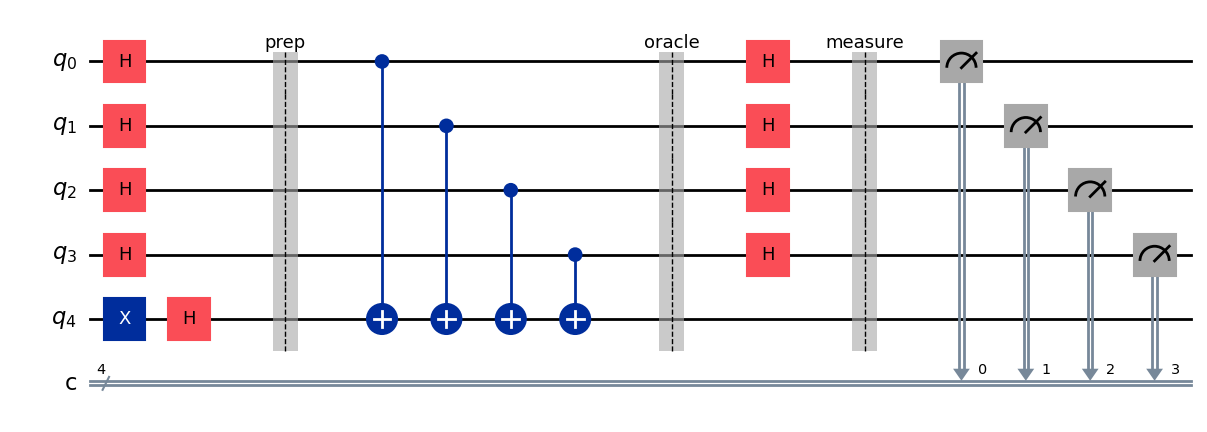

In [ ]:
n = 4
oracle = make_balanced_oracle(n)
dj_circuit = deutsch_jozsa_circuit(oracle, n)

print(dj_circuit)
dj_circuit.draw("mpl")

## 2. Run ideal simulator

Simulator counts: {'1111': 4096}
Dominant simulator bitstring: 1111
Deutsch-Jozsa classification: balanced


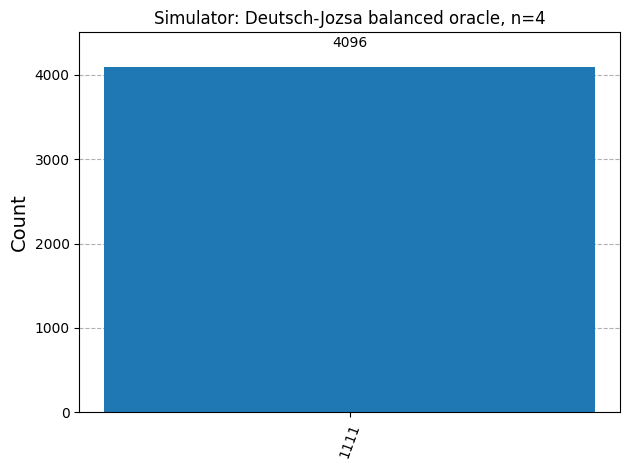

In [ ]:
simulator = AerSimulator()
transpiled = transpile(dj_circuit, simulator)
result = simulator.run(transpiled, shots=SHOTS).result()
counts_sim = result.get_counts()

dominant_sim = max(counts_sim, key=counts_sim.get)
classification_sim = classify_deutsch_jozsa_counts(counts_sim, n)

print("Simulator counts:", counts_sim)
print("Dominant simulator bitstring:", dominant_sim)
print("Deutsch-Jozsa classification:", classification_sim)

assert dominant_sim == "1" * n, "Expected the balanced oracle to produce all ones."
assert classification_sim == "balanced"

plot_histogram(counts_sim, title="Simulator: Deutsch-Jozsa balanced oracle, n=4")

## 3. Optional constant-oracle control check

This is useful for documentation because the constant case should produce `0000`.

Constant-oracle simulator counts: {'0000': 4096}
Dominant constant bitstring: 0000
Deutsch-Jozsa classification: constant


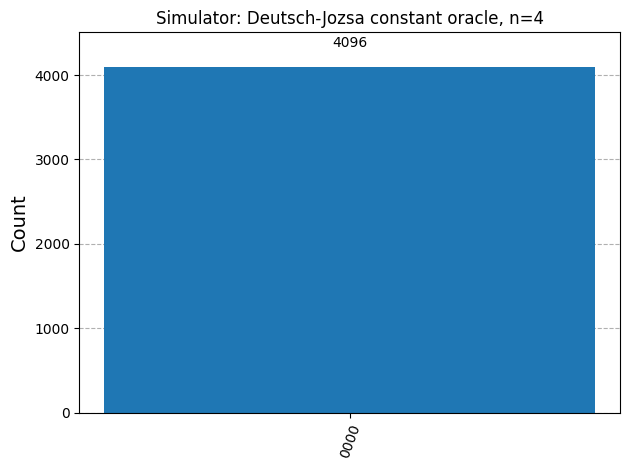

In [ ]:
constant_oracle = make_constant_oracle(n, output=0)
constant_circuit = deutsch_jozsa_circuit(constant_oracle, n)

transpiled_constant = transpile(constant_circuit, simulator)
constant_result = simulator.run(transpiled_constant, shots=SHOTS).result()
counts_constant = constant_result.get_counts()

dominant_constant = max(counts_constant, key=counts_constant.get)
classification_constant = classify_deutsch_jozsa_counts(counts_constant, n)

print("Constant-oracle simulator counts:", counts_constant)
print("Dominant constant bitstring:", dominant_constant)
print("Deutsch-Jozsa classification:", classification_constant)

assert dominant_constant == "0" * n
assert classification_constant == "constant"

plot_histogram(counts_constant, title="Simulator: Deutsch-Jozsa constant oracle, n=4")

## 4. Notes for comparison report

Fill this after the IBM hardware notebook is run.

| Field | Value |
|---|---|
| Algorithm | Deutsch-Jozsa |
| Input register size | 4 qubits |
| Total circuit qubits | 5 qubits including output/ancilla |
| Oracle type | Balanced, CNOT from each input qubit to output |
| Expected ideal bitstring | `1111` |
| Simulator dominant result | `1111` |
| Simulator classification | Balanced |